# Implementación del TFIM: Trotter, fidelidad, ED y VQE

El modelo de Ising con campo transverso (TFIM) en una cadena periódica es

$$
H=-J\sum_{i=0}^{N-1}Z_iZ_{i+1}-h\sum_{i=0}^{N-1}X_i,
\qquad Z_N=Z_0.
$$

La interacción $J$ favorece el orden ferromagnético en $Z$, mientras que el
campo $h$ favorece la polarización en $X$. En el límite termodinámico ambas
tendencias compiten en $h/J=1$.

Este notebook sigue los cinco objetivos del reto:

1. evolución temporal trotterizada y degradación con el tamaño;
2. dinámica de $\langle Z\rangle$ y $\langle Z_iZ_j\rangle$;
3. comparación de los regímenes $h/J\in\{0.5,1,2\}$;
4. validación por diagonalización exacta (ED) con 6 qubits;
5. un único VQE de 6 espines por cada valor de $h/J$.

Todas las funciones están en `funciones_ising_hackathon.py`. El notebook
conserva solamente parámetros, experimentos, tablas e interpretación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from funciones_ising_hackathon import *

estilo_graficas_tfim()
np.set_printoptions(precision=5, suppress=True)

## Parámetros reproducibles

Usamos frontera periódica y el estado producto

$$
|\psi(0)\rangle=|0\rangle^{\otimes N}.
$$

Este estado tiene $\langle M_z\rangle=1$ y
$\langle C_{ZZ}\rangle=1$. La ED y el VQE se restringen a $N=6$; el escalado
Trotter se ejecuta ahora entre 4 y 12 espines.

In [2]:
J = 1.0
campos = (0.5, 1.0, 2.0)
campos_vqe = tuple(np.round(np.arange(0.2, 2.01, 0.2), 1))
n_ed = 6
r_dinamica = 20
tiempos = np.linspace(0.0, 3.0, 31)
semilla_vqe = 17

print(f"ED y VQE: N={n_ed}")
print(f"Campos de din?mica y ED: {campos}")
print(f"Barrido VQE ({len(campos_vqe)} puntos): {campos_vqe}")
print(f"Dinámica: {len(tiempos)} tiempos, r={r_dinamica}")

ED y VQE: N=6
Campos de din?mica y ED: (0.5, 1.0, 2.0)
Barrido VQE (10 puntos): (np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6), np.float64(1.8), np.float64(2.0))
Dinámica: 31 tiempos, r=20


## Herramientas num?ricas

- **Qiskit:** construye los circuitos de Trotter, simula sus vectores de estado y representa los operadores del TFIM. Tambi?n permite comparar la evoluci?n contra ED para $N=6$.
- **PennyLane:** define el circuito variacional diferenciable del VQE y calcula gradientes para que Adam minimice la energ?a.
- **Diagonalizaci?n exacta (ED):** proporciona la referencia cl?sica de energ?a, estado y observables. Su costo crece como $2^N$, por eso se usa solamente con 6 espines.

La **trotterizaci?n** aproxima una evoluci?n dif?cil mediante pasos cortos de t?rminos implementables. El **VQE** es un ciclo h?brido: un circuito prepara $|\psi(\theta)\rangle$ y un optimizador cl?sico minimiza

$$
E(\theta)=\langle\psi(\theta)|H|\psi(\theta)\rangle\geq E_0.
$$

Ambas herramientas resuelven preguntas distintas: Trotter estudia din?mica temporal; VQE aproxima el estado fundamental.

## 1. Evolución de Trotter y convergencia

Separamos $H=H_{ZZ}+H_X$ y usamos Trotter de primer orden:

$$
e^{-iH\tau}\approx
\left(e^{-iH_{ZZ}\Delta\tau}e^{-iH_X\Delta\tau}\right)^r,
\qquad \Delta\tau=\frac{\tau}{r}.
$$

Como $H_{ZZ}$ y $H_X$ no conmutan, reducir $\Delta\tau$ debe aumentar la
fidelidad

$$
F=|\langle\psi_{\mathrm{ED}}|\psi_{\mathrm{Trotter}}\rangle|^2.
$$

In [3]:
circuito_ejemplo = circuito_tfim_trotter_cerrado(
    J=J, h=J, n_q=n_ed, r=4, t=1.0
)
print("Ejemplo N=6, h/J=1, r=4")
print("Δτ =", 1.0 / 4)
print("Profundidad =", circuito_ejemplo.depth())
print("Compuertas =", circuito_ejemplo.size())

Ejemplo N=6, h/J=1, r=4
Δτ = 0.25
Profundidad = 28
Compuertas = 48


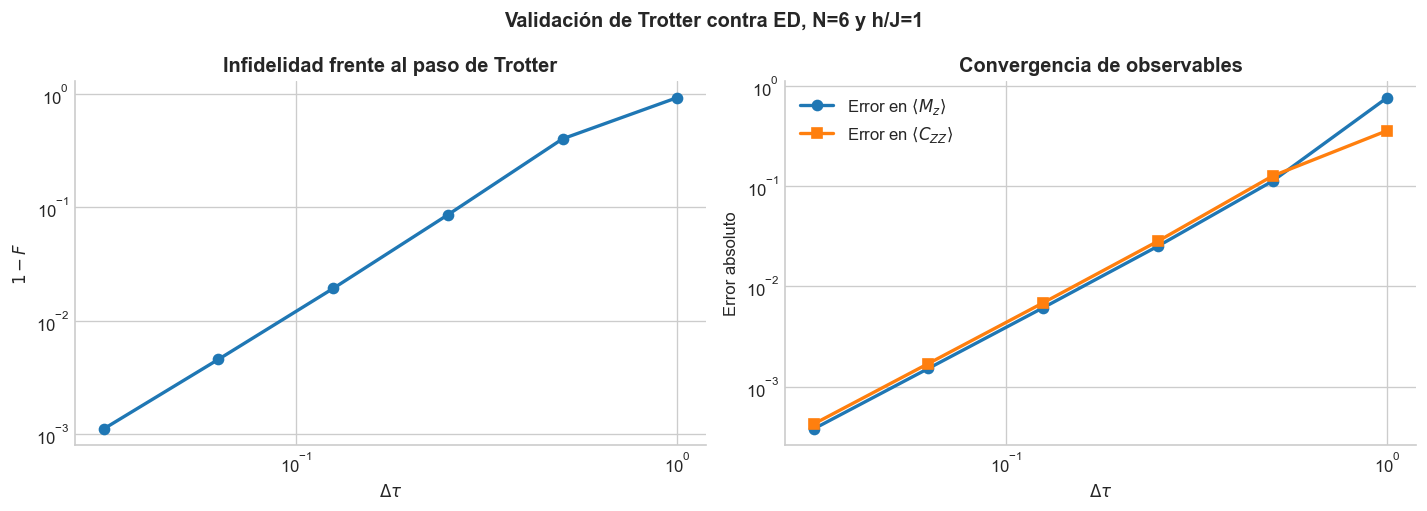

In [4]:
valores_r = np.array([1, 2, 4, 8, 16, 32])
convergencia = convergencia_trotter_tfim(
    valores_r, J=J, h=J, n_q=n_ed, t=1.0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].loglog(
    convergencia["dt"],
    1 - convergencia["fidelidad"],
    "o-", lw=2,
)
axes[0].set(
    xlabel=r"$\Delta\tau$",
    ylabel=r"$1-F$",
    title="Infidelidad frente al paso de Trotter",
)

axes[1].loglog(
    convergencia["dt"], convergencia["error_mz"],
    "o-", lw=2, label=r"Error en $\langle M_z\rangle$",
)
axes[1].loglog(
    convergencia["dt"], convergencia["error_czz"],
    "s-", lw=2, label=r"Error en $\langle C_{ZZ}\rangle$",
)
axes[1].set(
    xlabel=r"$\Delta\tau$",
    ylabel="Error absoluto",
    title="Convergencia de observables",
)
axes[1].legend()
fig.suptitle("Validación de Trotter contra ED, N=6 y h/J=1", fontweight="bold")
fig.tight_layout()
plt.show()

La fidelidad cuantifica el error del estado completo; los errores de
observables indican cuánto de ese error afecta las cantidades físicas que
reportamos. Ambas pruebas son necesarias: un observable aislado puede coincidir
aunque el estado global ya se haya degradado.

### Degradación con el tamaño: 4–12 espines

Para tamaños mayores que la ED práctica, comparamos las aproximaciones con $r$
y $2r$. Si ambas dejan de coincidir, el paso elegido ya no está convergido.
También registramos profundidad, número de compuertas, tiempo local y memoria
del vector de estado. La misma función acepta después tamaños de hasta 20.

In [5]:
escalado = escalado_trotter_tfim(
    tamanos=(4, 6, 8, 10, 12),
    J=J, h=J, r=4, t=1.0,
)

lineas = [
    "| $N$ | Profundidad | Compuertas | $F(r,2r)$ | Tiempo (s) | Memoria (MB) |",
    "|---:|---:|---:|---:|---:|---:|",
]
for fila in escalado:
    lineas.append(
        f"| {fila['n_q']} | {fila['profundidad']} | {fila['compuertas']} | "
        f"{fila['fidelidad_r_2r']:.6f} | {fila['tiempo_s']:.4f} | "
        f"{fila['memoria_estado_mb']:.4f} |"
    )
display(Markdown("\n".join(lineas)))

| $N$ | Profundidad | Compuertas | $F(r,2r)$ | Tiempo (s) | Memoria (MB) |
|---:|---:|---:|---:|---:|---:|
| 4 | 20 | 32 | 0.977711 | 0.0051 | 0.0002 |
| 6 | 28 | 48 | 0.974242 | 0.0075 | 0.0010 |
| 8 | 36 | 64 | 0.965857 | 0.0081 | 0.0039 |
| 10 | 44 | 80 | 0.957497 | 0.0105 | 0.0156 |
| 12 | 52 | 96 | 0.949215 | 0.0215 | 0.0625 |

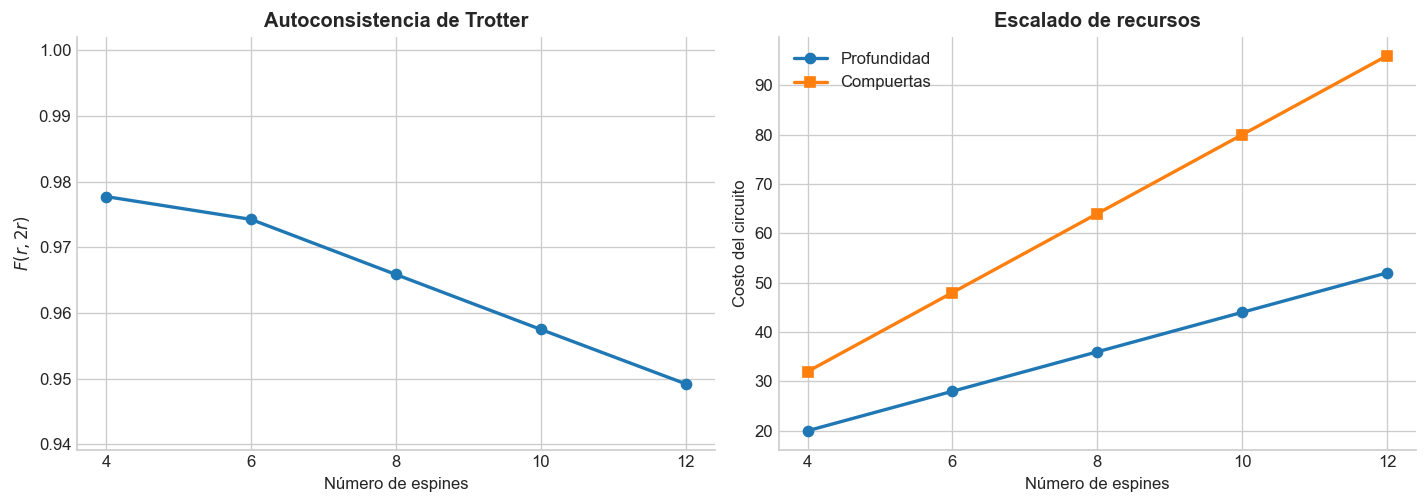

In [6]:
n_escalado = np.array([fila["n_q"] for fila in escalado])
f_escalado = np.array([fila["fidelidad_r_2r"] for fila in escalado])
profundidad = np.array([fila["profundidad"] for fila in escalado])
compuertas = np.array([fila["compuertas"] for fila in escalado])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(n_escalado, f_escalado, "o-", lw=2)
axes[0].set(
    xlabel="Número de espines",
    ylabel=r"$F(r,2r)$",
    title="Autoconsistencia de Trotter",
    xticks=n_escalado,
)
axes[0].set_ylim(min(f_escalado) - 0.01, 1.002)

axes[1].plot(n_escalado, profundidad, "o-", lw=2, label="Profundidad")
axes[1].plot(n_escalado, compuertas, "s-", lw=2, label="Compuertas")
axes[1].set(
    xlabel="Número de espines",
    ylabel="Costo del circuito",
    title="Escalado de recursos",
    xticks=n_escalado,
)
axes[1].legend()
fig.tight_layout()
plt.show()

Sí se observa degradación: con $r$ fijo, cada paso contiene más
términos y la infidelidad acumulada aumenta con $N$. Además, profundidad y
compuertas crecen linealmente, mientras la memoria de un simulador de
vector de estado crece como $2^N$. Esta corrida llega a $N=12$; extenderla
a $N=20$ requiere cambiar únicamente la lista `tamanos`.

## 2. Dinámica de $\langle Z\rangle$ y $\langle Z_iZ_j\rangle$

Medimos los promedios

$$
M_z=\frac{1}{N}\sum_i Z_i,
\qquad
C_{ZZ}=\frac{1}{N}\sum_i Z_iZ_{i+1}.
$$

Las líneas continuas son Trotter y las discontinuas ED. La fidelidad se evalúa
en cada tiempo, no solo al final.

In [7]:
dinamicas = {
    razon: dinamica_tfim_comparada(
        J=J, h=razon * J, n_q=n_ed,
        r=r_dinamica, tiempos=tiempos,
    )
    for razon in campos
}

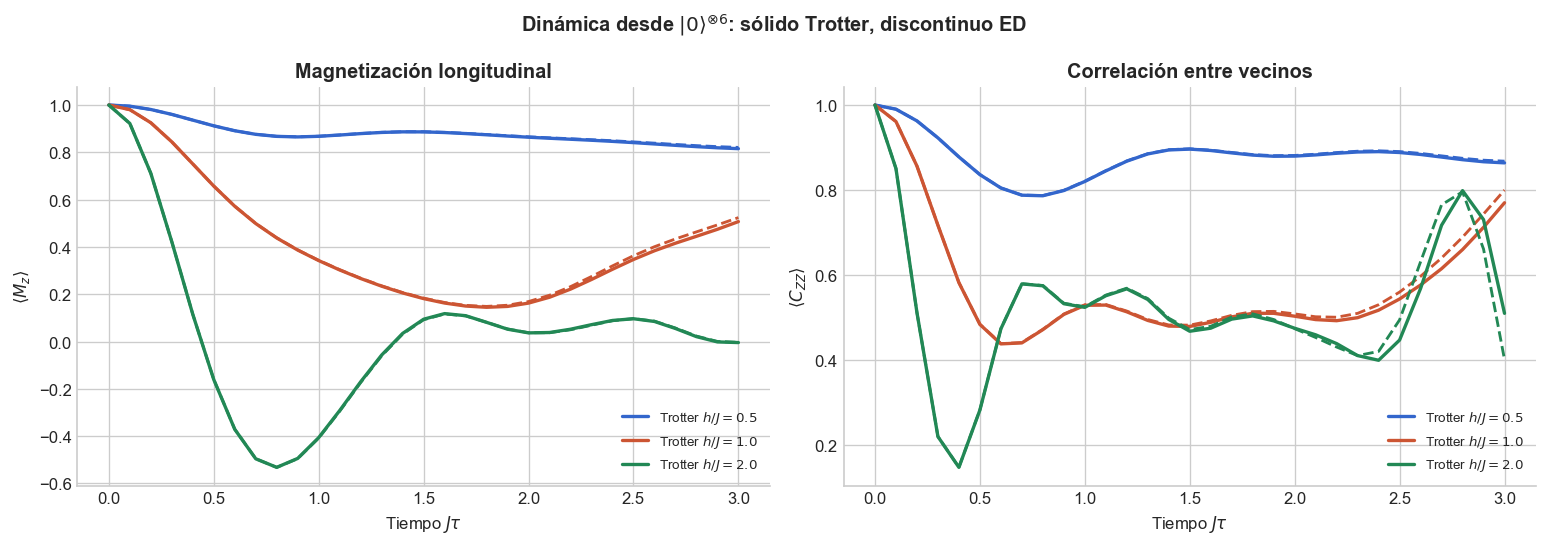

In [8]:
colores = {0.5: "#3366cc", 1.0: "#cc5533", 2.0: "#228855"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for razon, datos in dinamicas.items():
    color = colores[razon]
    axes[0].plot(
        datos["tiempos"], datos["mz_trotter"],
        color=color, lw=2, label=rf"Trotter $h/J={razon}$",
    )
    axes[0].plot(
        datos["tiempos"], datos["mz_exacta"],
        color=color, ls="--", lw=1.7,
    )
    axes[1].plot(
        datos["tiempos"], datos["czz_trotter"],
        color=color, lw=2, label=rf"Trotter $h/J={razon}$",
    )
    axes[1].plot(
        datos["tiempos"], datos["czz_exacta"],
        color=color, ls="--", lw=1.7,
    )

axes[0].set(
    xlabel=r"Tiempo $J\tau$",
    ylabel=r"$\langle M_z\rangle$",
    title="Magnetización longitudinal",
)
axes[1].set(
    xlabel=r"Tiempo $J\tau$",
    ylabel=r"$\langle C_{ZZ}\rangle$",
    title="Correlación entre vecinos",
)
for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle(r"Dinámica desde $|0\rangle^{\otimes 6}$: sólido Trotter, discontinuo ED", fontweight="bold")
fig.tight_layout()
plt.show()

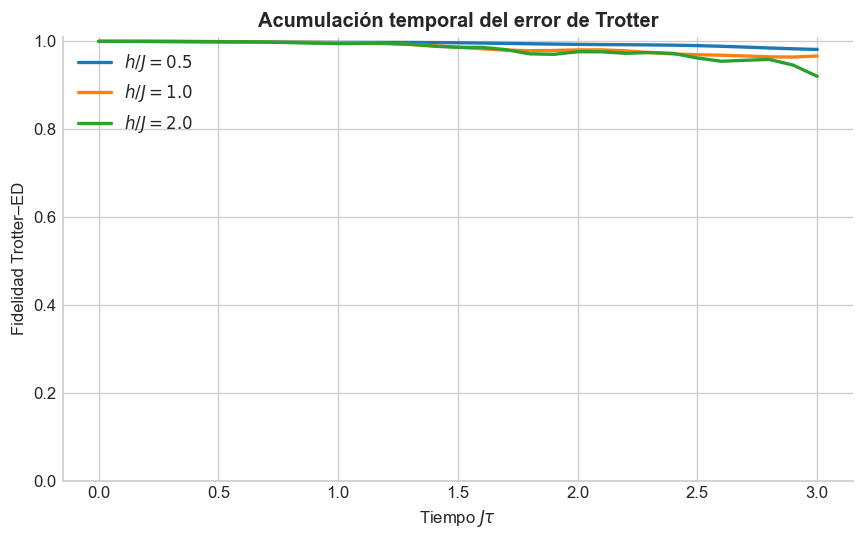

| $h/J$ | Fidelidad mínima | RMSE $M_z$ | RMSE $C_{ZZ}$ |
|---:|---:|---:|---:|
| 0.5 | 0.981615 | 2.113e-03 | 1.633e-03 |
| 1.0 | 0.964284 | 8.956e-03 | 1.212e-02 |
| 2.0 | 0.920426 | 1.604e-03 | 2.892e-02 |

In [9]:
fig, ax = plt.subplots()
for razon, datos in dinamicas.items():
    ax.plot(
        datos["tiempos"], datos["fidelidad"],
        lw=2, label=rf"$h/J={razon}$",
    )
ax.set(
    xlabel=r"Tiempo $J\tau$",
    ylabel="Fidelidad Trotter–ED",
    title="Acumulación temporal del error de Trotter",
)
ax.set_ylim(0, 1.01)
ax.legend()
plt.show()

lineas = [
    "| $h/J$ | Fidelidad mínima | RMSE $M_z$ | RMSE $C_{ZZ}$ |",
    "|---:|---:|---:|---:|",
]
for razon, datos in dinamicas.items():
    rmse_mz = np.sqrt(np.mean((datos["mz_trotter"] - datos["mz_exacta"]) ** 2))
    rmse_czz = np.sqrt(np.mean((datos["czz_trotter"] - datos["czz_exacta"]) ** 2))
    lineas.append(
        f"| {razon:.1f} | {datos['fidelidad'].min():.6f} | "
        f"{rmse_mz:.3e} | {rmse_czz:.3e} |"
    )
display(Markdown("\n".join(lineas)))

## 3. Barrido de $h/J$ y señal de la transición

Para un estado fundamental finito y simétrico,
$\langle M_z\rangle\approx0$ incluso en el régimen ferromagnético. Por ello
usamos $\sqrt{\langle M_z^2\rangle}$ como parámetro de orden longitudinal y
$\langle M_x\rangle$ como magnetización transversal.

En $N=6$ no existe una singularidad: la transición de $h/J=1$ aparece
redondeada por tamaño finito.

| $h/J$ | $E_0/N$ | $\langle M_z\rangle$ | $\sqrt{\langle M_z^2\rangle}$ | $\langle M_x\rangle$ | $C_{ZZ}$ |
|---:|---:|---:|---:|---:|---:|
| 0.5 | -1.064116 | 9.26e-13 | 0.969914 | 0.265198 | 0.931517 |
| 1.0 | -1.287901 | -2.99e-15 | 0.813220 | 0.643951 | 0.643951 |
| 2.0 | -2.128232 | 4.74e-17 | 0.554173 | 0.931517 | 0.265198 |

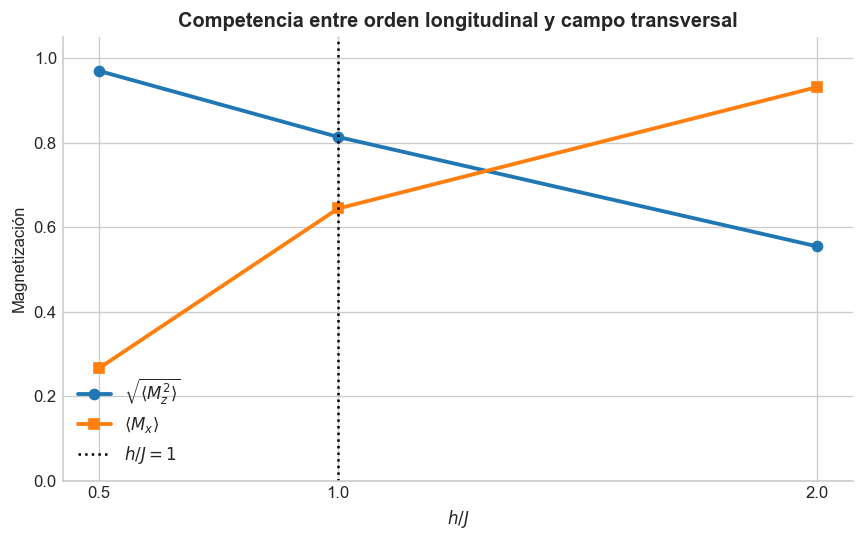

In [10]:
fase_ed = barrido_fase_ed_tfim(
    valores_h_sobre_J=campos, J=J, n_q=n_ed
)

lineas = [
    r"| $h/J$ | $E_0/N$ | $\langle M_z\rangle$ | "
    r"$\sqrt{\langle M_z^2\rangle}$ | $\langle M_x\rangle$ | $C_{ZZ}$ |",
    "|---:|---:|---:|---:|---:|---:|",
]
for fila in fase_ed:
    lineas.append(
        f"| {fila['h/J']:.1f} | {fila['E0/N']:.6f} | {fila['Mz']:.2e} | "
        f"{fila['sqrt_Mz2']:.6f} | {fila['Mx']:.6f} | {fila['Czz']:.6f} |"
    )
display(Markdown("\n".join(lineas)))

x_fase = np.array([fila["h/J"] for fila in fase_ed])
mz_fase = np.array([fila["sqrt_Mz2"] for fila in fase_ed])
mx_fase = np.array([fila["Mx"] for fila in fase_ed])

fig, ax = plt.subplots()
ax.plot(x_fase, mz_fase, "o-", lw=2.3, label=r"$\sqrt{\langle M_z^2\rangle}$")
ax.plot(x_fase, mx_fase, "s-", lw=2.3, label=r"$\langle M_x\rangle$")
ax.axvline(1.0, color="k", ls=":", label=r"$h/J=1$")
ax.set(
    xlabel=r"$h/J$",
    ylabel="Magnetización",
    title="Competencia entre orden longitudinal y campo transversal",
    xticks=x_fase,
)
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

## 4. Comparación frente a ED para 6 qubits

La ED se utilizó como referencia en tres lugares:

- convergencia al reducir $\Delta\tau$;
- fidelidad y RMSE durante toda la evolución;
- observables del estado fundamental en los tres regímenes.

Así se evita validar el circuito con una sola cifra. La comparación es sin
ruido, por lo que mide exclusivamente error de Trotter y no error de hardware.

## 5. VQE opcional: diez campos, una corrida por campo

Ejecutamos **exactamente un VQE de 6 espines** para cada punto

$$
h/J=0.2,0.4,\ldots,2.0.
$$

Todos usan la misma semilla, ansatz e hiperpar?metros; no hay reinicios ni selecci?n del mejor resultado. El ansatz combina rotaciones locales $R_XR_YR_Z$ con anillos de CNOT, mientras Adam minimiza la energ?a.

Usamos dos fidelidades:

$$
F_0=|\langle E_0|\psi_{VQE}\rangle|^2,
$$

que compara con un ?nico estado fundamental, y

$$
F_{\mathrm{sub}(2)}=
|\langle E_0|\psi_{VQE}\rangle|^2
+|\langle E_1|\psi_{VQE}\rangle|^2,
$$

que mide cu?nto peso permanece en el subespacio de los dos estados m?s bajos. Cuando el gap $E_1-E_0$ es peque?o, $F_0$ puede rondar $1/2$ aunque la energ?a y $F_{\mathrm{sub}(2)}$ sean buenas, porque el VQE puede seleccionar una rama ferromagn?tica distinta de la combinaci?n sim?trica de ED.

In [11]:
tabla_vqe, detalles_vqe = barrido_vqe_tfim_unico(
    valores_h_sobre_J=campos_vqe,
    J=J,
    n_layers=3,
    learning_rate=0.04,
    max_steps=400,
    seed=semilla_vqe,
)

lineas = [
    "| $h/J$ | $E_{VQE}/N$ | $E_{ED}/N$ | $|\Delta E|$ | "
    "$|\Delta E|/N$ | Error relativo | $F_0$ | $F_{sub(2)}$ | Pasos |",
    "|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for fila in tabla_vqe:
    lineas.append(
        f"| {fila['h/J']:.1f} | {fila['E_VQE/N']:.6f} | "
        f"{fila['E_ED/N']:.6f} | {fila['error_E']:.3e} | "
        f"{fila['error_E_por_spin']:.3e} | {fila['error_E_relativo_pct']:.2f}% | "
        f"{fila['fidelidad']:.6f} | {fila['fidelidad_subespacio_2']:.6f} | "
        f"{fila['pasos']} |"
    )
display(Markdown("### Benchmark energ?tico punto por punto\n\n" + "\n".join(lineas)))

errores_E = np.array([fila["error_E"] for fila in tabla_vqe])
errores_rel = np.array([fila["error_E_relativo_pct"] for fila in tabla_vqe])
fidelidades_0 = np.array([fila["fidelidad"] for fila in tabla_vqe])
fidelidades_2 = np.array([fila["fidelidad_subespacio_2"] for fila in tabla_vqe])
resumen = [
    ("MAE de energ?a", np.mean(errores_E)),
    ("RMSE de energ?a", np.sqrt(np.mean(errores_E**2))),
    ("Error absoluto m?ximo", np.max(errores_E)),
    ("Error relativo medio (%)", np.mean(errores_rel)),
    ("Fidelidad F0 media", np.mean(fidelidades_0)),
    ("Fidelidad Fsub(2) media", np.mean(fidelidades_2)),
    ("Fidelidad Fsub(2) m?nima", np.min(fidelidades_2)),
]
lineas_resumen = ["| M?trica global | Valor |", "|:---|---:|"]
lineas_resumen += [f"| {nombre} | {valor:.6f} |" for nombre, valor in resumen]
display(Markdown("### Resumen del benchmark\n\n" + "\n".join(lineas_resumen)))

lineas_obs = [
    "| $h/J$ | Error $M_z^2$ | Error $M_x$ | Error $C_{ZZ}$ | Gap ED |",
    "|---:|---:|---:|---:|---:|",
]
for fila in tabla_vqe:
    lineas_obs.append(
        f"| {fila['h/J']:.1f} | {fila['error_Mz2']:.3e} | "
        f"{fila['error_Mx']:.3e} | {fila['error_Czz']:.3e} | "
        f"{fila['gap_ED']:.3e} |"
    )
display(Markdown("### Error de observables\n\n" + "\n".join(lineas_obs)))

### Benchmark energ?tico punto por punto

| $h/J$ | $E_{VQE}/N$ | $E_{ED}/N$ | $|\Delta E|$ | $|\Delta E|/N$ | Error relativo | $F_0$ | $F_{sub(2)}$ | Pasos |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 0.2 | -1.010004 | -1.010028 | 1.421e-04 | 2.368e-05 | 0.00% | 0.499992 | 0.999967 | 168 |
| 0.4 | -1.040066 | -1.040574 | 3.048e-03 | 5.080e-04 | 0.05% | 0.499762 | 0.999410 | 175 |
| 0.6 | -1.090318 | -1.093834 | 2.110e-02 | 3.516e-03 | 0.32% | 0.498232 | 0.996358 | 400 |
| 0.8 | -1.160995 | -1.174801 | 8.283e-02 | 1.381e-02 | 1.18% | 0.492838 | 0.986689 | 400 |
| 1.0 | -1.252354 | -1.287901 | 2.133e-01 | 3.555e-02 | 2.76% | 0.488401 | 0.971129 | 400 |
| 1.2 | -1.364587 | -1.429666 | 3.905e-01 | 6.508e-02 | 4.55% | 0.505697 | 0.961679 | 400 |
| 1.4 | -1.590017 | -1.590841 | 4.945e-03 | 8.242e-04 | 0.05% | 0.999302 | 0.999306 | 400 |
| 1.6 | -1.734558 | -1.763699 | 1.748e-01 | 2.914e-02 | 1.65% | 0.970174 | 0.970174 | 400 |
| 1.8 | -1.918326 | -1.943674 | 1.521e-01 | 2.535e-02 | 1.30% | 0.977110 | 0.977110 | 400 |
| 2.0 | -2.105852 | -2.128232 | 1.343e-01 | 2.238e-02 | 1.05% | 0.982000 | 0.982001 | 400 |

### Resumen del benchmark

| M?trica global | Valor |
|:---|---:|
| MAE de energ?a | 0.117704 |
| RMSE de energ?a | 0.166443 |
| Error absoluto m?ximo | 0.390475 |
| Error relativo medio (%) | 1.291966 |
| Fidelidad F0 media | 0.691351 |
| Fidelidad Fsub(2) media | 0.984382 |
| Fidelidad Fsub(2) m?nima | 0.961679 |

### Error de observables

| $h/J$ | Error $M_z^2$ | Error $M_x$ | Error $C_{ZZ}$ | Gap ED |
|---:|---:|---:|---:|---:|
| 0.2 | 9.846e-05 | 5.031e-04 | 7.693e-05 | 3.100e-05 |
| 0.4 | 2.240e-03 | 5.900e-03 | 1.852e-03 | 1.885e-03 |
| 0.6 | 1.583e-02 | 2.829e-02 | 1.346e-02 | 1.944e-02 |
| 0.8 | 5.834e-02 | 7.895e-02 | 4.936e-02 | 9.167e-02 |
| 1.0 | 1.215e-01 | 1.351e-01 | 9.960e-02 | 2.633e-01 |
| 1.2 | 1.542e-01 | 1.515e-01 | 1.167e-01 | 5.351e-01 |
| 1.4 | 6.900e-03 | 2.249e-03 | 3.973e-03 | 8.709e-01 |
| 1.6 | 5.620e-02 | 2.172e-02 | 6.389e-02 | 1.239e+00 |
| 1.8 | 4.566e-02 | 1.672e-02 | 5.544e-02 | 1.623e+00 |
| 2.0 | 3.729e-02 | 1.302e-02 | 4.843e-02 | 2.014e+00 |

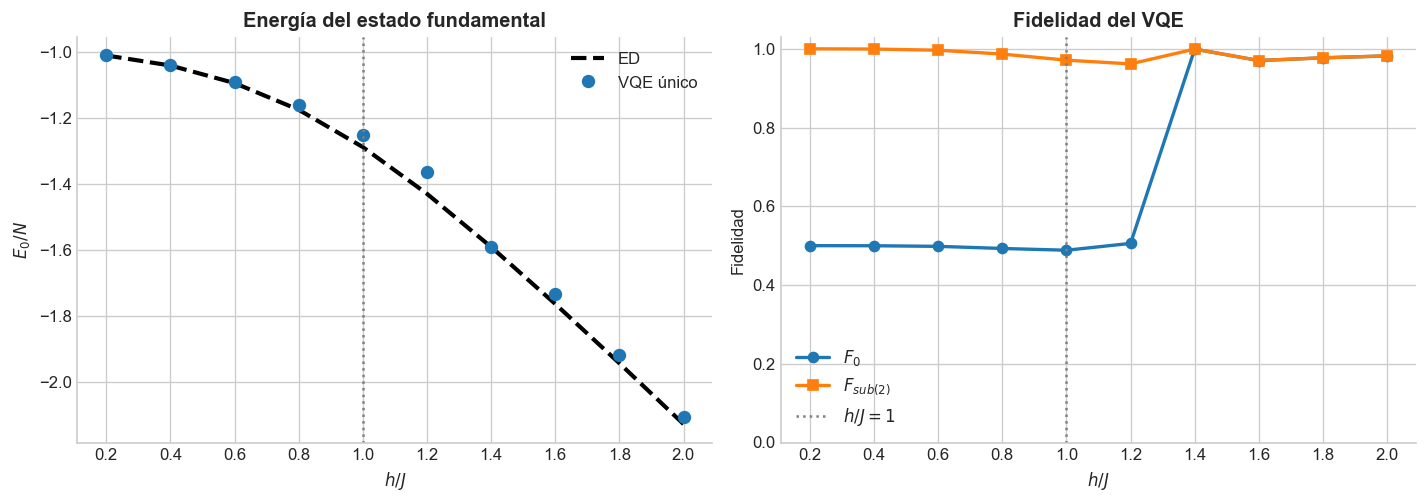

In [12]:
x_vqe = np.array([fila["h/J"] for fila in tabla_vqe])
e_vqe = np.array([fila["E_VQE/N"] for fila in tabla_vqe])
e_ed = np.array([fila["E_ED/N"] for fila in tabla_vqe])
f0 = np.array([fila["fidelidad"] for fila in tabla_vqe])
f2 = np.array([fila["fidelidad_subespacio_2"] for fila in tabla_vqe])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(x_vqe, e_ed, "k--", lw=2.5, label="ED")
axes[0].plot(x_vqe, e_vqe, "o", ms=7, label="VQE único")
axes[0].set(
    xlabel=r"$h/J$", ylabel=r"$E_0/N$",
    title="Energía del estado fundamental", xticks=x_vqe,
)
axes[0].axvline(1.0, color="0.5", ls=":")
axes[0].legend()

axes[1].plot(x_vqe, f0, "o-", lw=2, label=r"$F_0$")
axes[1].plot(x_vqe, f2, "s-", lw=2, label=r"$F_{sub(2)}$")
axes[1].set(
    xlabel=r"$h/J$", ylabel="Fidelidad",
    title="Fidelidad del VQE", xticks=x_vqe,
)
axes[1].axvline(1.0, color="0.5", ls=":", label=r"$h/J=1$")
axes[1].set_ylim(0, 1.03)
axes[1].legend()
fig.tight_layout()
plt.show()

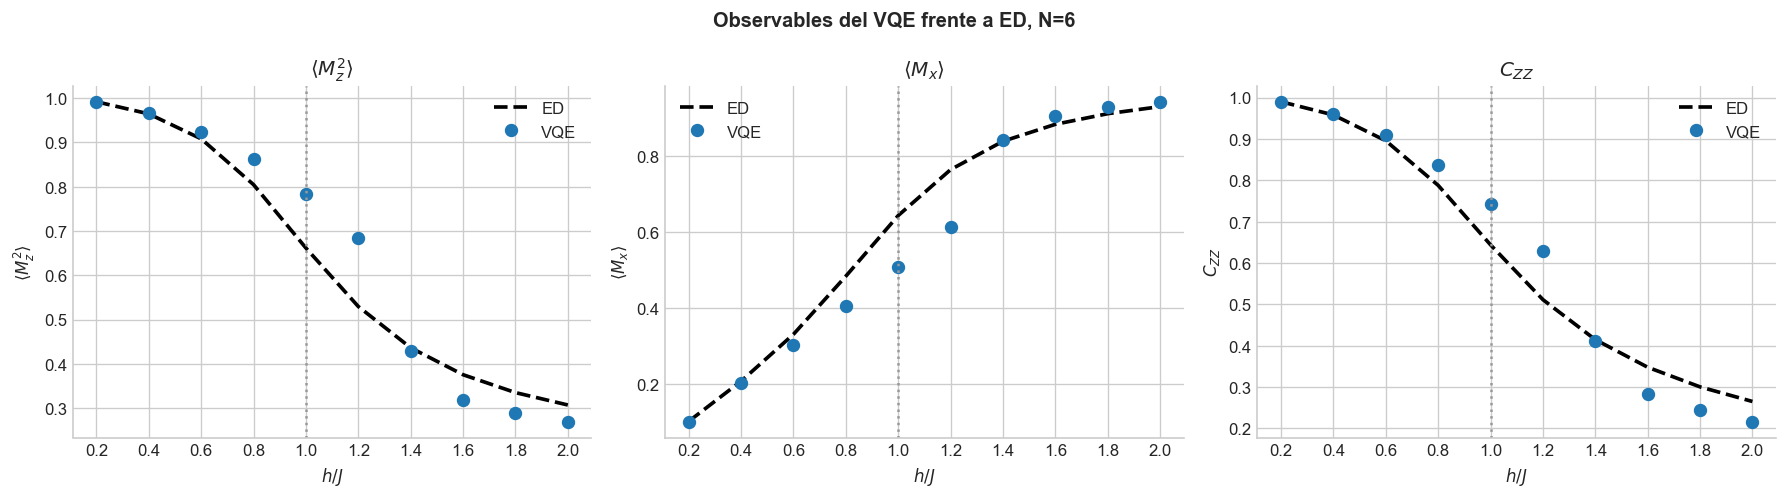

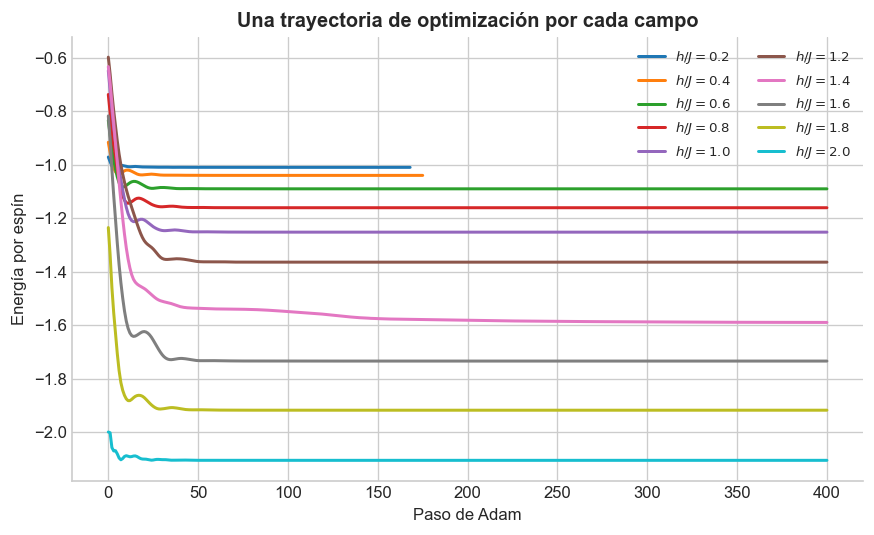

In [13]:
comparaciones = [
    ("Mz2_VQE", "Mz2_ED", r"$\langle M_z^2\rangle$"),
    ("Mx_VQE", "Mx_ED", r"$\langle M_x\rangle$"),
    ("Czz_VQE", "Czz_ED", r"$C_{ZZ}$"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (clave_vqe, clave_ed, ylabel) in zip(axes, comparaciones):
    y_vqe = [fila[clave_vqe] for fila in tabla_vqe]
    y_ed = [fila[clave_ed] for fila in tabla_vqe]
    ax.plot(x_vqe, y_ed, "k--", lw=2.2, label="ED")
    ax.plot(x_vqe, y_vqe, "o", ms=7, label="VQE")
    ax.set(xlabel=r"$h/J$", ylabel=ylabel, title=ylabel, xticks=x_vqe)
    ax.axvline(1.0, color="0.6", ls=":")
    ax.legend()
fig.suptitle("Observables del VQE frente a ED, N=6", fontweight="bold")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots()
for razon, resultado in detalles_vqe.items():
    ax.plot(resultado["historial"] / n_ed, lw=1.8, label=rf"$h/J={razon}$")
ax.set(
    xlabel="Paso de Adam",
    ylabel="Energía por espín",
    title="Una trayectoria de optimización por cada campo",
)
ax.legend(ncol=2, fontsize=8)
plt.show()

En el régimen ferromagnético, $F_0$ puede acercarse a $1/2$ aunque la
energía y los observables sean precisos: el VQE puede seleccionar una rama
simetría-rota, mientras ED devuelve el estado par tipo *cat*.
$F_{\mathrm{sub}(2)}$ revela si el estado permanece dentro del subespacio
físico casi degenerado. Cerca del punto crítico la optimización es más difícil
por el cierre de la brecha y la mayor correlación del estado.

## Conclusiones y limitaciones honestas

1. Reducir $\Delta\tau$ mejora sistemáticamente la fidelidad Trotter–ED.
2. Con $r$ fijo, la autoconsistencia empeora entre 4 y 12 espines y el costo del
   circuito crece linealmente; la memoria clásica crece exponencialmente.
3. $\langle M_z\rangle$ y $C_{ZZ}$ distinguen la dinámica de los tres campos,
   mientras $\sqrt{\langle M_z^2\rangle}$ y $\langle M_x\rangle$ muestran el
   cambio de régimen del estado fundamental.
4. Para $N=6$ la transición está redondeada: no debe interpretarse como una
   singularidad termodinámica.
5. El VQE usa una sola corrida por campo. Sus fallos no se ocultan mediante
   reinicios o selección de la mejor semilla.
6. Todo se ejecuta en simulación ideal. En hardware, profundidad, ruido y
   errores de lectura degradarían adicionalmente los resultados.